In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [9]:
speech = pd.read_stata('speech_data.dta')
voting = pd.read_stata('vote_data.dta')

## Descriptive Statistics

In [10]:
speech['against_only'] = (speech['vote_outcome'] == 2).astype(int)

variables = ['against_only', 'vote_against', 'gal_tan','v4_d' ,'nordic_d', 'pigs_d', 'eurobar_climate_problem_std', 'log_GDP_pc_std', 'renewable_share_std', 'log_emissions_pc_std',
             'gender_num']

stats_df = pd.DataFrame(index=variables, 
                        columns=['Observations', 'Mean', 'SD', 'Min', 'Max'])

for var in variables:
    stats_df.loc[var, 'Observations'] = speech[var].count()
    stats_df.loc[var, 'Mean'] = speech[var].mean()
    stats_df.loc[var, 'SD'] = speech[var].std()
    stats_df.loc[var, 'Min'] = speech[var].min()
    stats_df.loc[var, 'Max'] = speech[var].max()

stats_df = stats_df.apply(pd.to_numeric)
stats_df = stats_df.round(2)

stats_df

,Observations,Mean,SD,Min,Max
against_only,12760,0.07,0.25,0.00,1.00
vote_against,12760,0.12,0.33,0.00,1.00
gal_tan,12400,1.72,0.52,1.00,3.00
v4_d,12760,0.11,0.31,0.00,1.00
nordic_d,12760,0.06,0.23,0.00,1.00
pigs_d,12760,0.30,0.46,0.00,1.00
eurobar_climate_problem_std,11783,2.69,0.45,0.00,3.91
log_GDP_pc_std,12760,0.06,0.84,-2.36,2.40
renewable_share_std,11737,-0.02,0.82,-1.57,3.84
log_emissions_pc_std,12760,-0.25,0.81,-2.33,3.27


In [11]:
voting['against_only'] = (voting['vote_outcome'] == 2).astype(int)

variables = ['against_only', 'vote_against', 'gal_tan','v4_d' ,'nordic_d', 'pigs_d', 'eurobar_climate_problem_std', 'log_GDP_pc_std', 'renewable_share_std', 'log_emissions_pc_std',
             'gender_num']

stats_df = pd.DataFrame(index=variables, 
                        columns=['Observations', 'Mean', 'SD', 'Min', 'Max'])

for var in variables:
    stats_df.loc[var, 'Observations'] = voting[var].count()
    stats_df.loc[var, 'Mean'] = voting[var].mean()
    stats_df.loc[var, 'SD'] = voting[var].std()
    stats_df.loc[var, 'Min'] = voting[var].min()
    stats_df.loc[var, 'Max'] = voting[var].max()

stats_df = stats_df.apply(pd.to_numeric)
stats_df = stats_df.round(2)

stats_df

,Observations,Mean,SD,Min,Max
against_only,42598,0.10,0.30,0.00,1.00
vote_against,42598,0.14,0.35,0.00,1.00
gal_tan,40909,1.81,0.60,1.00,3.00
v4_d,42223,0.13,0.33,0.00,1.00
nordic_d,42223,0.06,0.24,0.00,1.00
pigs_d,42223,0.22,0.42,0.00,1.00
eurobar_climate_problem_std,39588,2.68,0.47,0.00,3.91
log_GDP_pc_std,42223,0.15,0.82,-2.36,2.40
renewable_share_std,38823,-0.10,0.82,-1.58,3.84
log_emissions_pc_std,42223,-0.11,0.77,-2.36,3.27


## Evaluation of LLM Classification Performance

### First-Stage Classification Evaluation


Classification Report:
                   precision  recall  f1-score  support
Denialist             0.9079  1.0000    0.9517    69.00
Fatalistic            0.7121  0.9400    0.8103    50.00
None                  0.9359  0.7935    0.8588    92.00
Solution-oriented     0.9750  0.8764    0.9231    89.00
accuracy              0.8900  0.8900    0.8900     0.89
macro avg             0.8827  0.9025    0.8860   300.00
weighted avg          0.9038  0.8900    0.8912   300.00


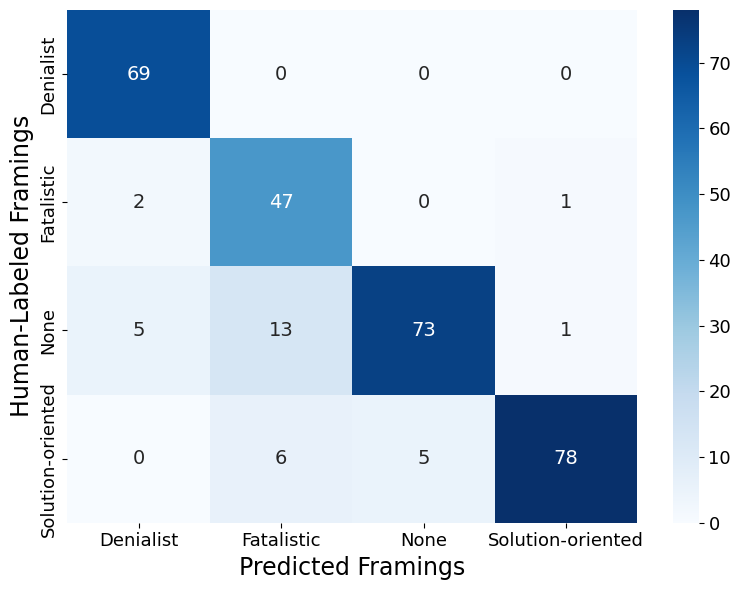

In [12]:
# Load dataset with human-annotated speeches
evaluation_df = pd.read_csv('evaluation_df.csv')

# Add predicted classes
evaluation_df = evaluation_df.merge(
    speech[['ID', 'framing_final']],
    on='ID',
    how='left'
)

# Rename classes
evaluation_df = evaluation_df.replace({
    "denialist": "Denialist",
    "fatalistic": "Fatalistic",
    "none": "None",
    "solution-oriented": "Solution-oriented"
})

def calculate_framing_metrics(df):
    y_true = df['framing_manual']
    y_pred = df['framing_final']

    accuracy = accuracy_score(y_true, y_pred)

    labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    report = classification_report(y_true, y_pred, labels=labels, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nClassification Report:")
    print(report_df.round(4))

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar_kws={'label': 'Count'},
        annot_kws={"size": 14},
        ax=ax
    )

    ax.set_xlabel('Predicted Framings', fontsize=17)
    ax.set_ylabel('Human-Labeled Framings', fontsize=17)
    ax.tick_params(axis='both', labelsize=13)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)
    cbar.ax.set_ylabel('', fontsize=14)

    plt.tight_layout()

    return accuracy, cm_df, report_df


result = calculate_framing_metrics(evaluation_df)

### Second-Stage Classification Evaluation


Classification Report:
                             precision  recall  f1-score   support
Solution-oriented Passive       0.8741  0.8194    0.8459  144.0000
Solution-oriented Proactive     0.8424  0.8910    0.8660  156.0000
accuracy                        0.8567  0.8567    0.8567    0.8567
macro avg                       0.8582  0.8552    0.8560  300.0000
weighted avg                    0.8576  0.8567    0.8564  300.0000


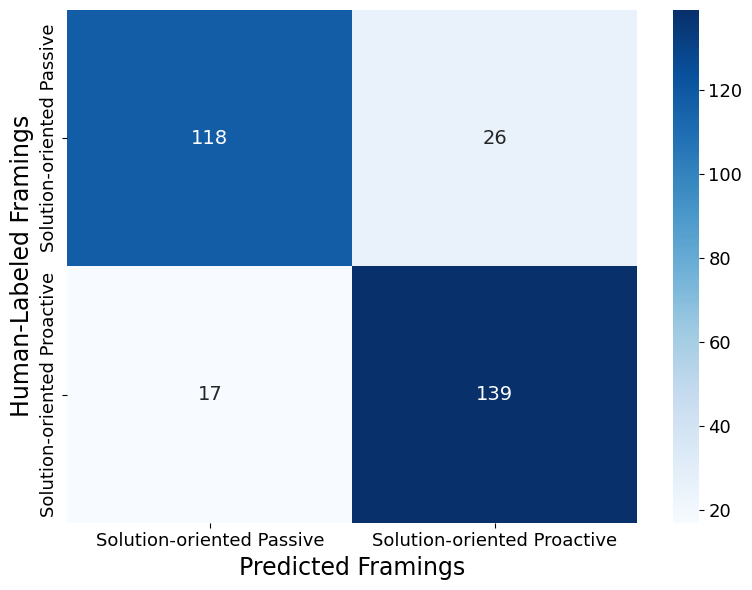

In [13]:
# Load dataset with human-annotated speeches
evaluation_df_detailed = pd.read_csv('evaluation_df_detailed.csv')

# Add predicted classes
evaluation_df_detailed = evaluation_df_detailed.merge(
    speech[['ID', 'framing_final_detailed']],
    on='ID',
    how='left'
)

evaluation_df_detailed = evaluation_df_detailed.replace({
    "Solution-oriented_passive": "Solution-oriented Passive",
    "Solution-oriented_proactive": "Solution-oriented Proactive"
})

def calculate_framing_metrics(df):
    y_true = df['framing_manual']
    y_pred = df['framing_final_detailed']

    accuracy = accuracy_score(y_true, y_pred)

    labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    report = classification_report(y_true, y_pred, labels=labels, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nClassification Report:")
    print(report_df.round(4))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar_kws={'label': 'Count'},
        annot_kws={"size": 14},
        ax=ax
    )
    ax.set_xlabel('Predicted Framings', fontsize=17)
    ax.set_ylabel('Human-Labeled Framings', fontsize=17)
    ax.tick_params(axis='both', labelsize=13)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)
    cbar.ax.set_ylabel('', fontsize=14)
    plt.tight_layout()
    
    return accuracy, cm_df, report_df

result = calculate_framing_metrics(evaluation_df_detailed)